# 05 — مقارنة FP-Growth وApriori

تقارن هذه الدفترية الصحة قبل السرعة. تستخدم الخوارزميتان مصفوفة UK نفسها، وMinimum Support=0.5%، و`max_len=3`، وترتيب الأعمدة والمعالجة والبيئة نفسها.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

from src.data.paths import PROJECT_ROOT, project_path
from src.mining.basket_loader import load_prepared_basket
from src.mining.pipeline import run_comparison_experiment

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
prepared = load_prepared_basket()
print(prepared.matrix.shape, prepared.matrix.nnz)

(17901, 3791) 473636


## منهج المقارنة

ينفذ Warm-up واحداً ثم ثلاث تشغيلات مقاسة لكل خوارزمية على البيانات الكاملة، ويعرض median wall-clock time. قياس الذاكرة هو RSS قبل/بعد فقط وليس Peak Memory. يستخدم Apriori وضع `low_memory=True` لحماية الموارد من دون تغيير Support أو `max_len`.

In [2]:
comparison_result = run_comparison_experiment()
comparison_result

ComparisonExperimentSummary(fpgrowth_median_runtime_seconds=20.276707599987276, apriori_median_runtime_seconds=25.26851040008478, equivalent=True, common_itemsets=18681, maximum_support_difference=0.0)

## تكافؤ Frequent Itemsets

In [3]:
equivalence = json.loads(project_path("outputs", "comparisons", "itemset_equivalence_summary.json").read_text(encoding="utf-8"))
display(pd.DataFrame([equivalence]))
assert equivalence["equivalent"]
assert equivalence["fpgrowth_only_itemsets"] == 0
assert equivalence["apriori_only_itemsets"] == 0

,absolute_tolerance,apriori_only_itemsets,common_itemsets,equivalent,fpgrowth_only_itemsets,maximum_support_difference
0,1.000000e-12,0,18681,True,0,0.0


تُطابق Itemsets بمفتاح canonical مرتب، وتقارن قيم Support بتسامح مطلق `1e-12`. لا تصبح مقارنة الوقت ذات معنى قبل نجاح هذا الفحص.

## Runtime والذاكرة التقريبية

In [4]:
benchmark = pd.read_csv(project_path("outputs", "comparisons", "fpgrowth_apriori_benchmark.csv"))
measured = benchmark.loc[benchmark.run_type.eq("measured")]
display(benchmark)
display(measured.groupby("algorithm").agg(
    measured_runs=("runtime_seconds", "size"),
    median_runtime_seconds=("runtime_seconds", "median"),
    median_approximate_rss_delta_bytes=("approximate_rss_delta_bytes", "median"),
))

,algorithm,run_type,run_index,status,transaction_count,product_count,minimum_support,minimum_support_count,maximum_length,frequent_itemset_count,runtime_seconds,rss_before_bytes,rss_after_bytes,approximate_rss_delta_bytes,memory_measurement
0,FP-Growth,warmup,0,success,17901,3791,0.005,90,3,18681,20.830857,193392640,371937280,178544640,approximate process RSS before/after; not peak...
1,Apriori,warmup,0,success,17901,3791,0.005,90,3,18681,26.107365,372297728,222289920,-150007808,approximate process RSS before/after; not peak...
2,FP-Growth,measured,1,success,17901,3791,0.005,90,3,18681,20.276708,223686656,361127936,137441280,approximate process RSS before/after; not peak...
3,Apriori,measured,1,success,17901,3791,0.005,90,3,18681,29.777156,361373696,362553344,1179648,approximate process RSS before/after; not peak...
4,FP-Growth,measured,2,success,17901,3791,0.005,90,3,18681,21.283593,361578496,369475584,7897088,approximate process RSS before/after; not peak...
5,Apriori,measured,2,success,17901,3791,0.005,90,3,18681,25.268510,369786880,371179520,1392640,approximate process RSS before/after; not peak...
6,FP-Growth,measured,3,success,17901,3791,0.005,90,3,18681,19.585992,369254400,386404352,17149952,approximate process RSS before/after; not peak...
7,Apriori,measured,3,success,17901,3791,0.005,90,3,18681,23.380900,386662400,388894720,2232320,approximate process RSS before/after; not peak...


,measured_runs,median_runtime_seconds,median_approximate_rss_delta_bytes
algorithm,,,
Apriori,3,25.268510,1392640.0
FP-Growth,3,20.276708,17149952.0


لا تمثل RSS delta قمة الذاكرة، وقد تكون سالبة بسبب تحرير الذاكرة وGarbage Collection. لذلك لا تُستخدم لإعلان تفوق ذاكرة قطعي.

## Scalability على كسور حتمية متطابقة

In [5]:
scalability = pd.read_csv(project_path("outputs", "comparisons", "scalability_experiment.csv"))
display(scalability[["algorithm", "transaction_fraction", "transaction_count", "minimum_support_count", "frequent_itemset_count", "runtime_seconds"]])

,algorithm,transaction_fraction,transaction_count,minimum_support_count,frequent_itemset_count,runtime_seconds
0,FP-Growth,0.25,4475,23,138140,21.304710
1,Apriori,0.25,4475,23,138140,22.589901
2,FP-Growth,0.50,8950,45,16451,8.293898
3,Apriori,0.50,8950,45,16451,11.829422
4,FP-Growth,0.75,13425,68,14477,11.057937
5,Apriori,0.75,13425,68,14477,15.375255
6,FP-Growth,1.00,17901,90,18681,19.704219
7,Apriori,1.00,17901,90,18681,22.864033


تستخدم كل نقطة مقدمة حتمية من ترتيب معاملات Phase 3 نفسه للخوارزميتين. الزمن ليس ملزماً بالزيادة مع عدد الصفوف: عند 25% يصبح Support count صغيراً، وقد تظهر أنماط كثيرة خاصة بتلك الفترة. هذا يوضح أن تكلفة التعدين تتأثر بعدد الأنماط وتركيب البيانات، لا بعدد المعاملات وحده.

## رسوم المقارنة

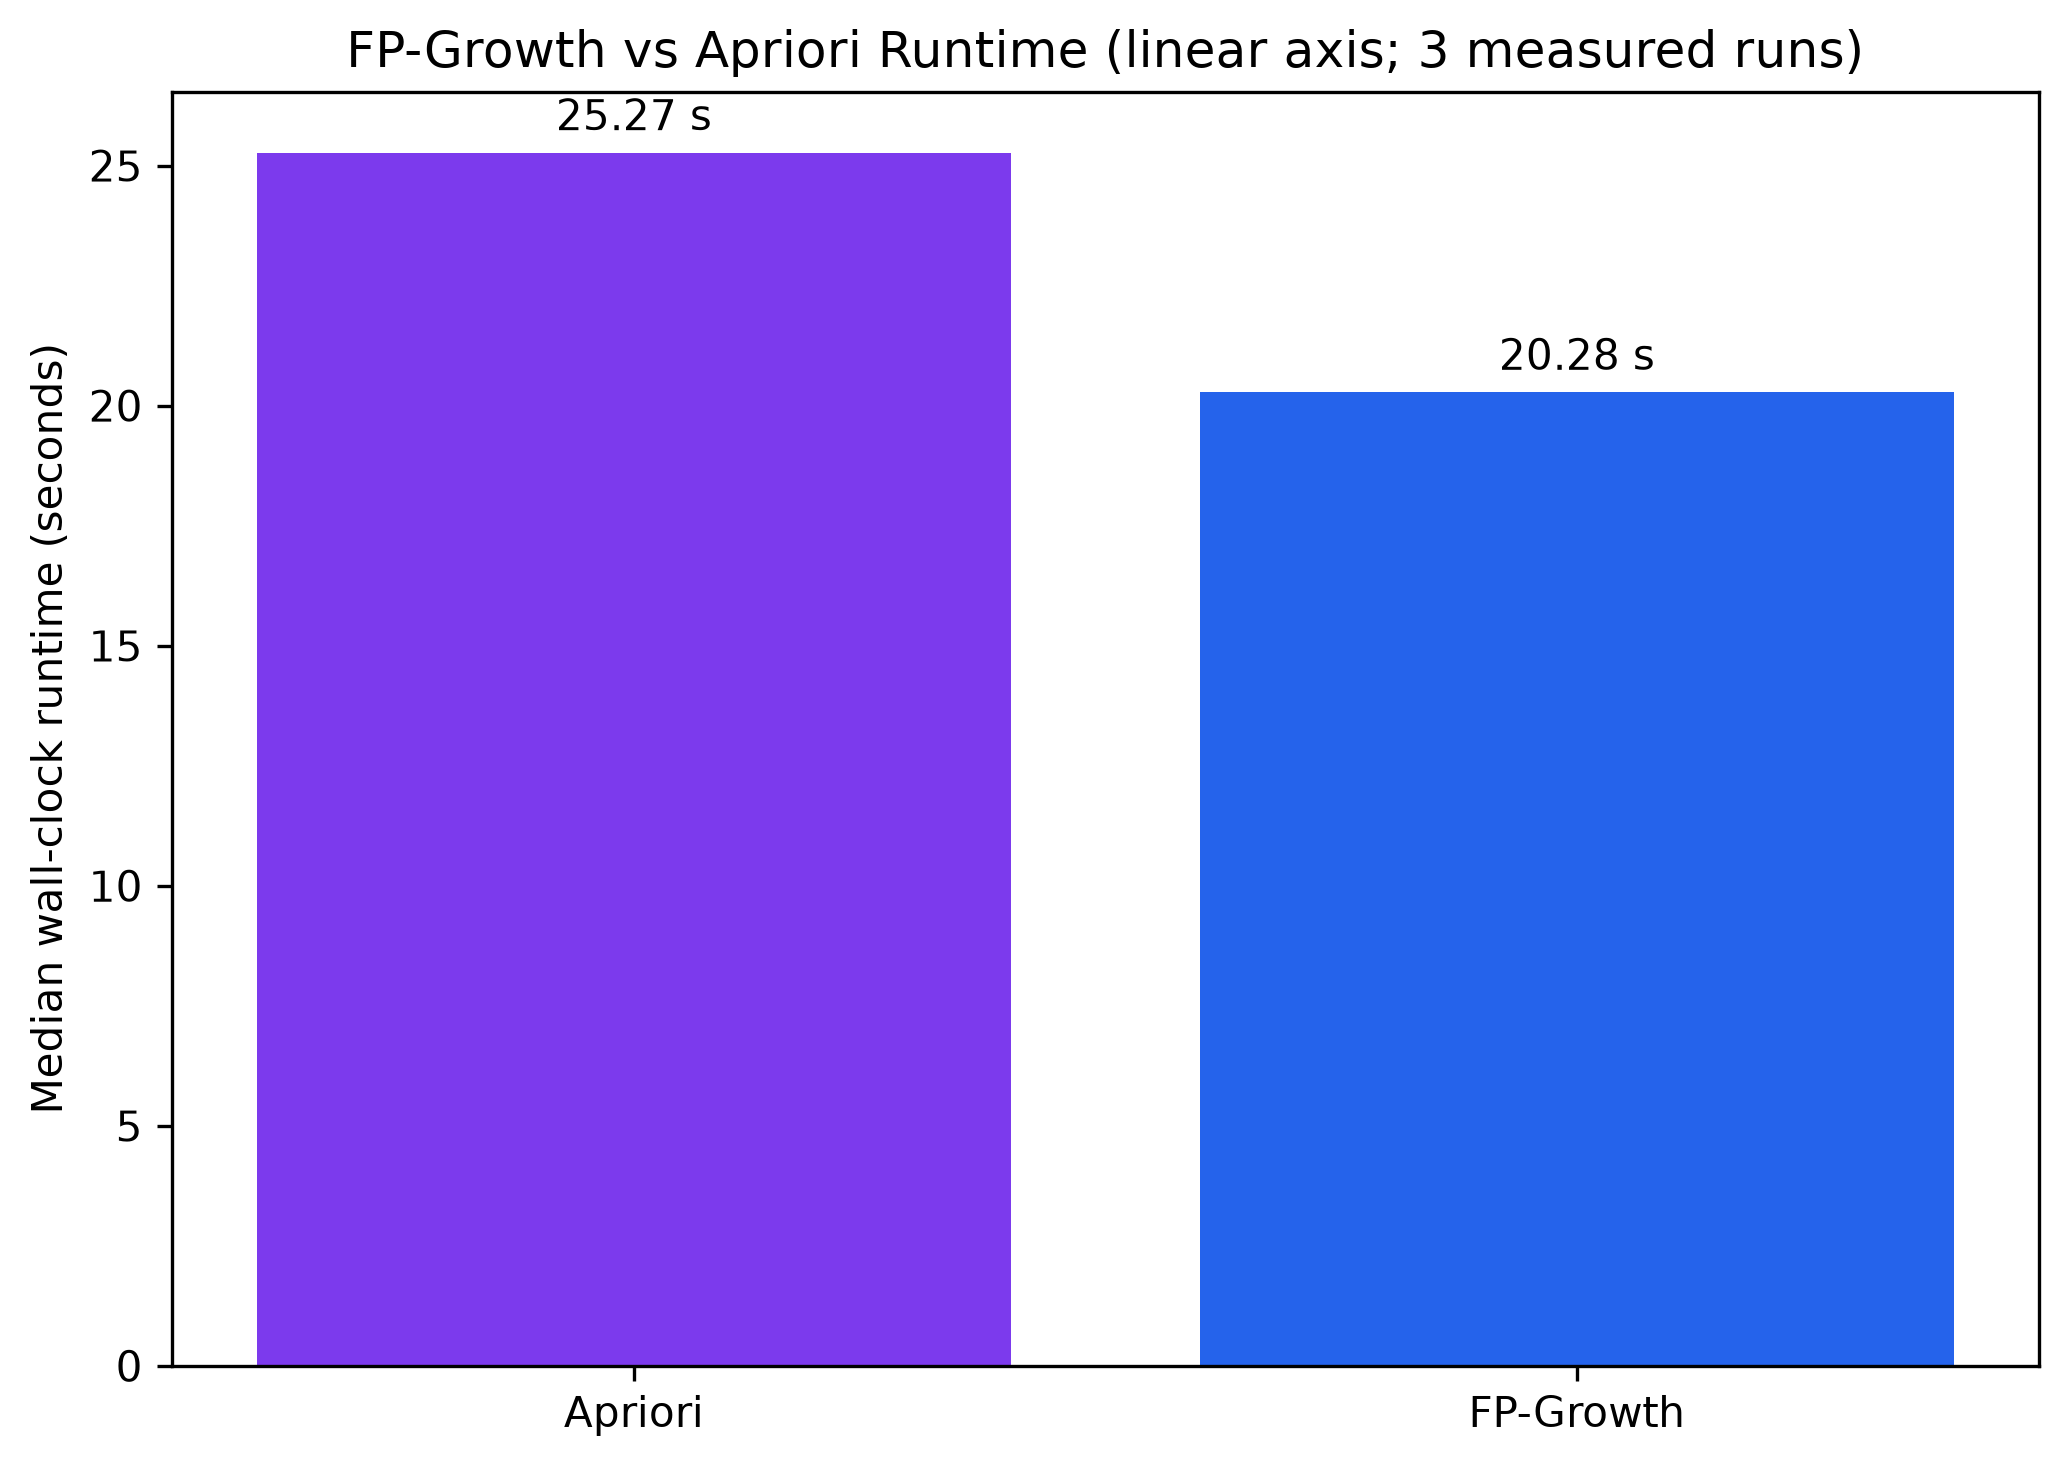

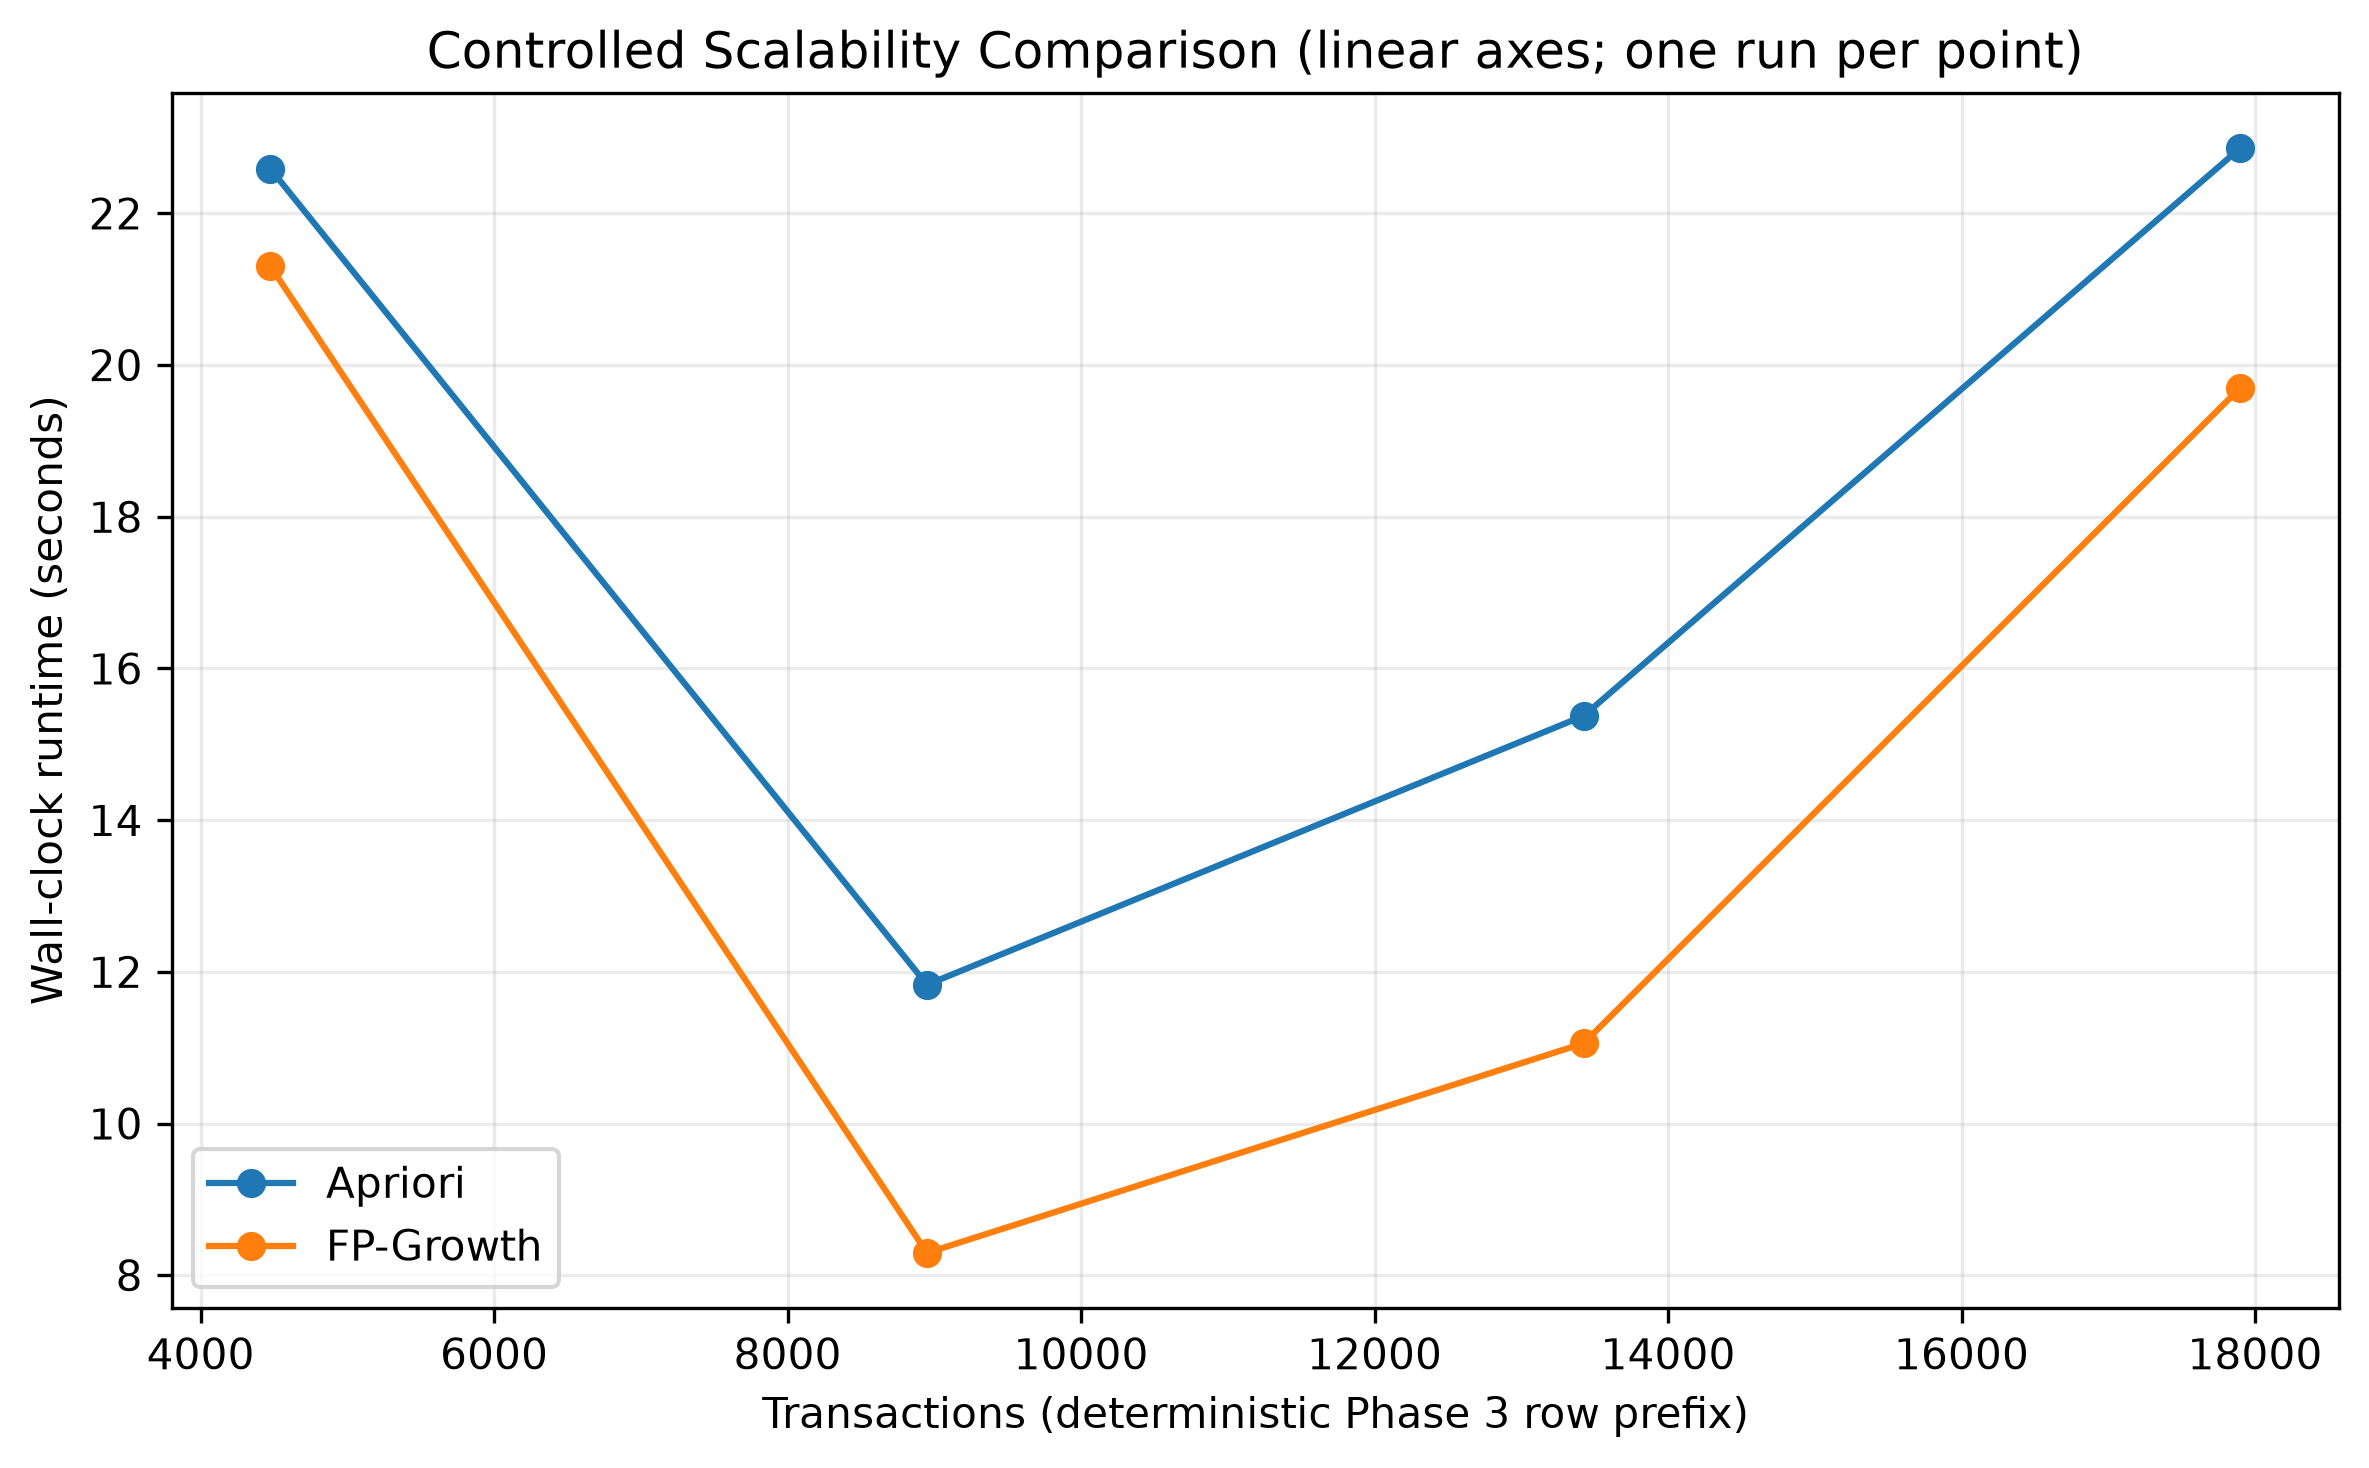

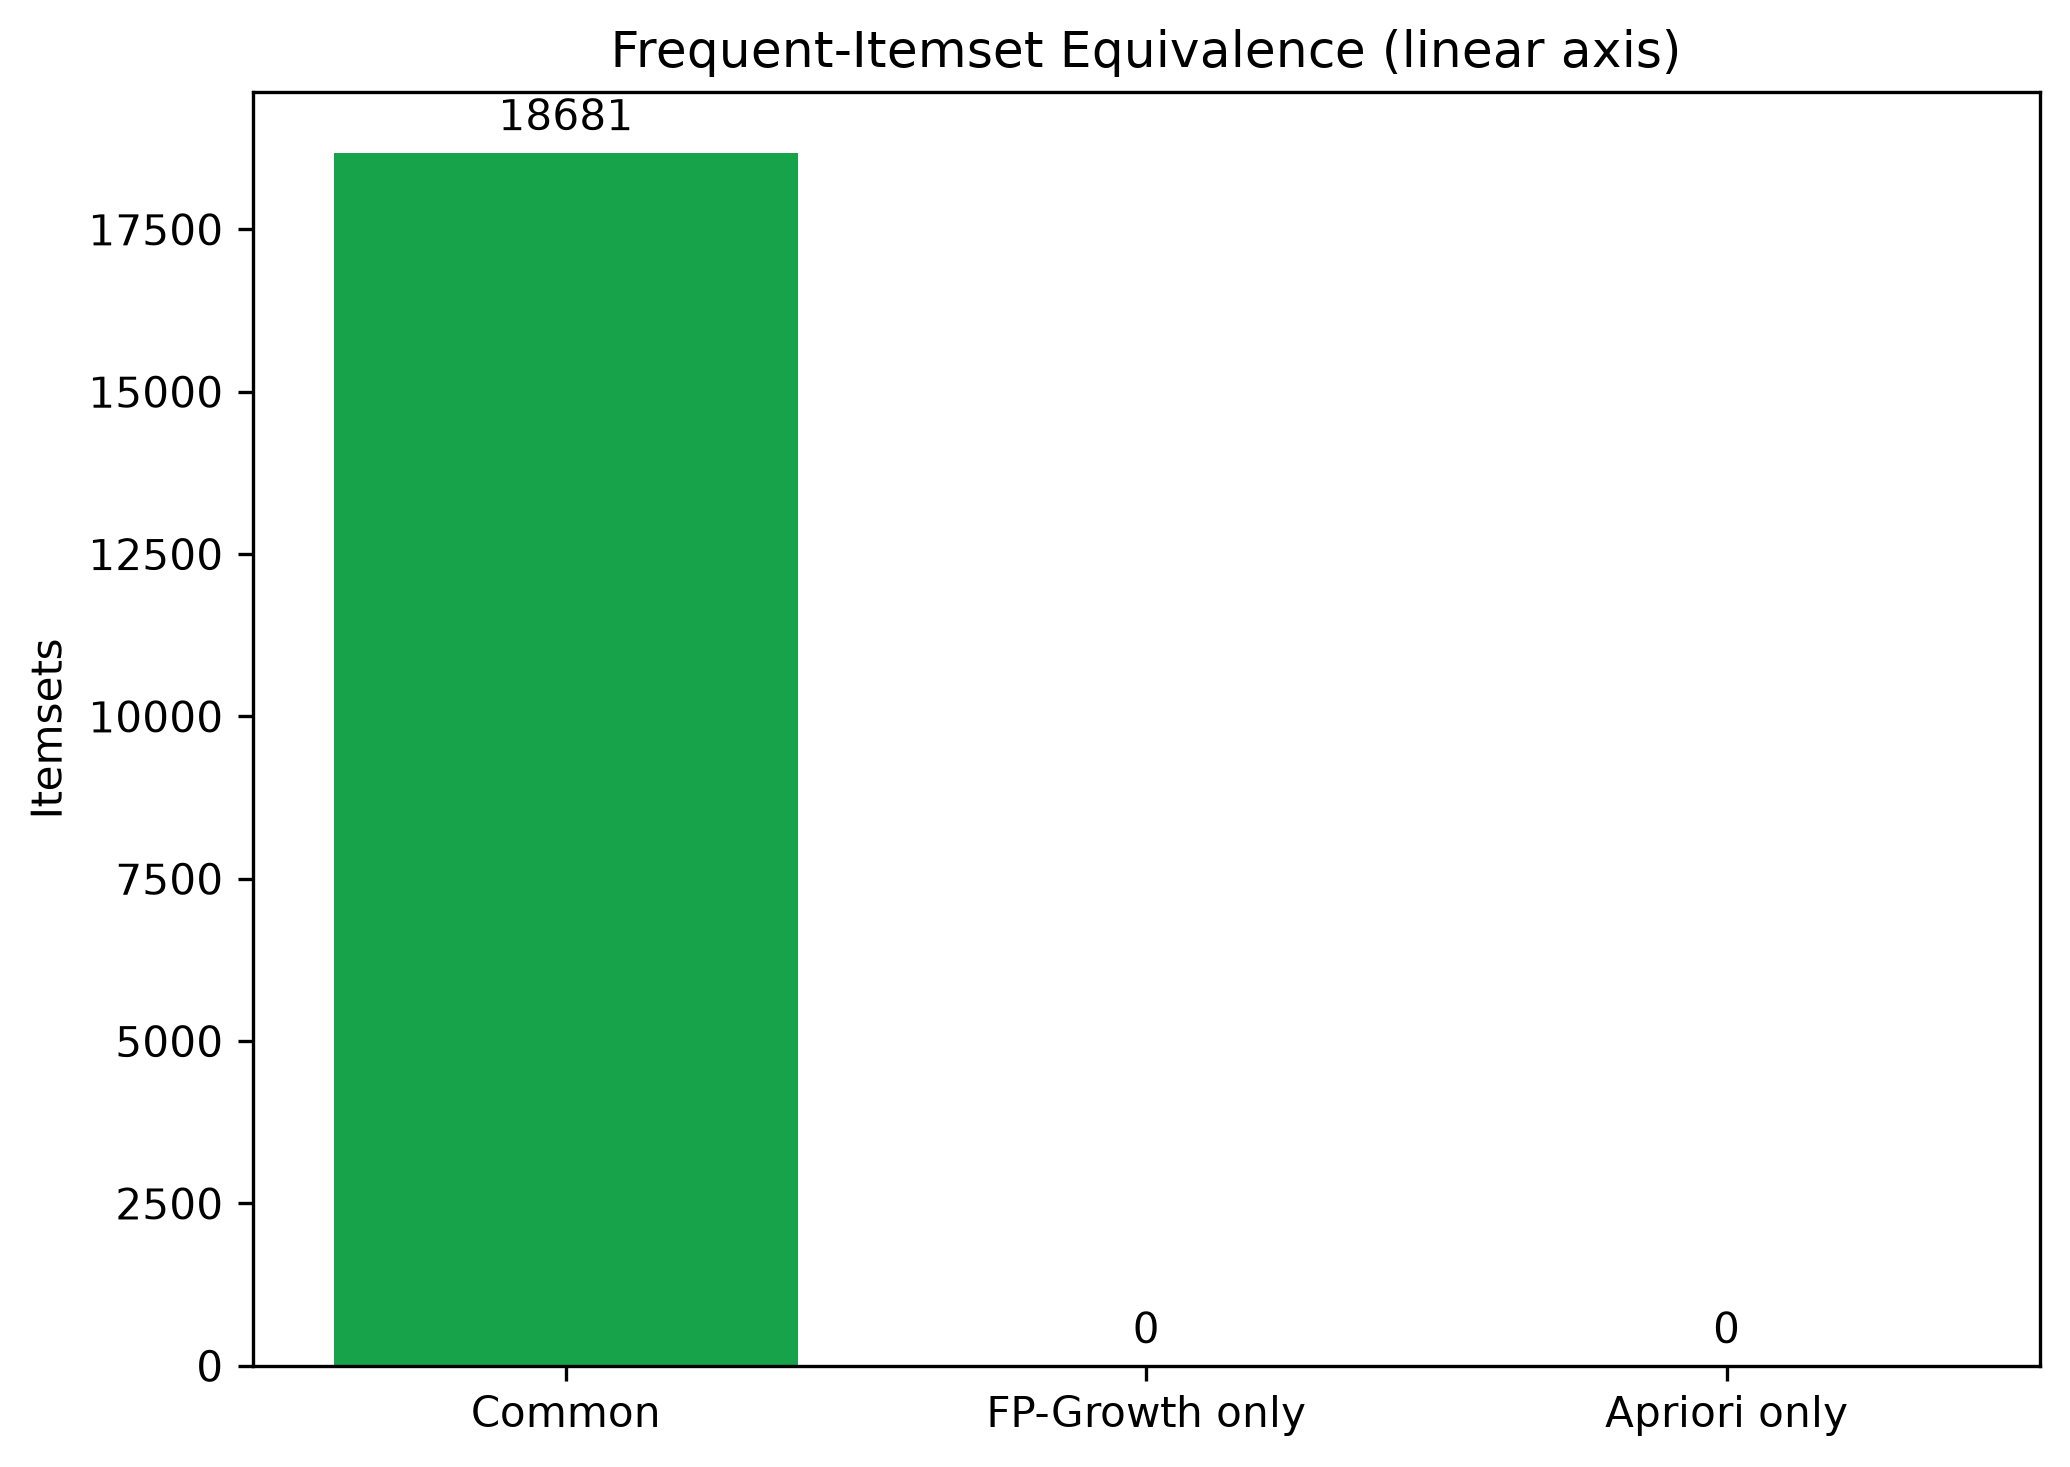

In [6]:
for filename in [
    "fpgrowth_vs_apriori_runtime.png",
    "scalability_fpgrowth_vs_apriori.png",
    "itemset_equivalence_summary.png",
]:
    display(Image(filename=str(project_path("outputs", "figures", filename)), width=900))

## التفسير والقيود

النتيجة تقيس هذا dataset وهذا التطبيق والإصدارات والجهاز والإعدادات فقط، ولا تثبت تفوقاً عاماً. `max_len=3` يمنع مقارنة الأنماط الأطول، وscalability تستخدم time-ordered prefixes لا عينات ممثلة. أصبحت شروط المقارنة موثقة لتجربة WEKA لاحقاً، لكن WEKA لم يُنفذ في Phase 4، كما لم تبدأ أدوات Phase 5 التفاعلية أو Bootstrap.